In [2]:
# importing packages
import pyomo.environ as pyo
import numpy as np
from matplotlib import pyplot as plt
import math
import scipy.stats as stats
from scipy.optimize import fsolve, bisect
import pandas as pd
import equivalent_conductivity as eq
import multicomponent_conductivity as mc

# Three-Salt System Conductivity Predictions

## Load Data

In [47]:
data = pd.read_csv("./Data/three_salts_1.csv")
NaCl_conc = data["NaCl_conc"]
CaCl2_conc = data["CaCl2_conc"]
LaCl3_conc = data["LaCl3_conc"]
cond_exp = data["Cal_bulk_cond"]

# number of data points
ndata = len(cond_exp)

In [48]:
data2 = pd.read_csv("./Data/three_salts_2.csv")
NaCl_conc2 = data2["NaCl_conc"]
CaCl2_conc2 = data2["CaCl2_conc"]
LaCl3_conc2 = data2["LaCl3_conc"]
cond_exp2 = data2["Cal_bulk_cond"]

# number of data points
ndata2 = len(cond_exp2)

In [49]:
data3 = pd.read_csv("./Data/three_salts_3.csv")
NaCl_conc3 = data3["NaCl_conc"]
CaCl2_conc3 = data3["CaCl2_conc"]
LaCl3_conc3 = data3["LaCl3_conc"]
cond_exp3 = data3["Cal_bulk_cond"]

# number of data points
ndata3 = len(cond_exp3)

## Constants

In [50]:
# temperature
T = 298.15

# diffusion coefficients at infinite dilution
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)
Diff_Ca = 0.792 * 10**(-9)
Diff_La = 0.619 * 10**(-9)

# valencies
z_Na = 1
z_Cl = -1
z_Ca = 2
z_La = 3

# measuring voltage and probe distance
voltage = 25 * 10**(-3)
distance = 9 * 10**(-6)

# hard sphere diameters
sigma_Cl = 181 * 10**(-12)
sigma_Ca = 100 * 10**(-12)
sigma_La = 103.2 * 10**(-12)
sigma_Na = 102 * 10**(-12)

# solvent viscosity
eta = 0.89 * 10**(-3)

# electric field
E_field = voltage/distance

# relative permittivity
epsilon = 78.4

## MSA Transport Model

# Shedlovsky Model

## Data 1

In [51]:
# constants
temp = 298.16 # K
epsilon = 78.3
eta = 8.903*10**(-3) # poise
lambda_0_NaCl = 126.45 # cm^2.Siemen.equiv^(-1)
lambda_0_CaCl2 = 135.85 # cm^2.Siemen.equiv^(-1)
lambda_0_LaCl3 = 145.9 # cm^2.Siemen.equiv^(-1)
lambda_0_Na = 50.10 # cm^2.Siemen.equiv^(-1)
lambda_0_Ca = 59.5 # cm^2.Siemen.equiv^(-1)
lambda_0_La = 69.7 # cm^2.Siemen.equiv^(-1)
lambda_0_Cl = 76.35 # cm^2.Siemen.equiv^(-1)
a_NaCl = 4*10**(-8) # cm
a_CaCl2 = 4.31*10**(-8) # cm
a_LaCl3 = 4.9*10**(-8) # cm
a = (a_NaCl + a_CaCl2 + a_LaCl3)/3

# concentration in M from data1
conc_NaCl = [NaCl_conc[i]*10**(-3) for i in range(ndata)]
conc_CaCl2 = [CaCl2_conc[i]*10**(-3) for i in range(ndata)]
conc_LaCl3 = [LaCl3_conc[i]*10**(-3) for i in range(ndata)]

# concentration in M from data2
conc_NaCl_2 = [NaCl_conc2[i]*10**(-3) for i in range(ndata2)]
conc_CaCl2_2 = [CaCl2_conc2[i]*10**(-3) for i in range(ndata2)]
conc_LaCl3_2 = [LaCl3_conc2[i]*10**(-3) for i in range(ndata2)]

# concentration in M from data3
conc_NaCl_3 = [NaCl_conc3[i]*10**(-3) for i in range(ndata3)]
conc_CaCl2_3 = [CaCl2_conc3[i]*10**(-3) for i in range(ndata3)]
conc_LaCl3_3 = [LaCl3_conc3[i]*10**(-3) for i in range(ndata3)]

# specific conductivity in micro Siemen per cm for data 1
specific_cond_NaCl = eq.specific_cond_model(conc_NaCl, temp, epsilon, eta, lambda_0_NaCl, a, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)
specific_cond_CaCl2 = eq.specific_cond_model(conc_CaCl2, temp, epsilon, eta, lambda_0_CaCl2, a, z_Ca, z_Cl, lambda_0_Ca, lambda_0_Cl)
specific_cond_LaCl3 = eq.specific_cond_model(conc_LaCl3, temp, epsilon, eta, lambda_0_LaCl3, a, z_La, z_Cl, lambda_0_La, lambda_0_Cl)

# specific conductivity in micro Siemen per cm for data 2
specific_cond_NaCl_2 = eq.specific_cond_model(conc_NaCl_2, temp, epsilon, eta, lambda_0_NaCl, a, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)
specific_cond_CaCl2_2 = eq.specific_cond_model(conc_CaCl2_2, temp, epsilon, eta, lambda_0_CaCl2, a, z_Ca, z_Cl, lambda_0_Ca, lambda_0_Cl)
specific_cond_LaCl3_2 = eq.specific_cond_model(conc_LaCl3_2, temp, epsilon, eta, lambda_0_LaCl3, a, z_La, z_Cl, lambda_0_La, lambda_0_Cl)

# specific conductivity in micro Siemen per cm for data 3
specific_cond_NaCl_3 = eq.specific_cond_model(conc_NaCl_3, temp, epsilon, eta, lambda_0_NaCl, a, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)
specific_cond_CaCl2_3 = eq.specific_cond_model(conc_CaCl2_3, temp, epsilon, eta, lambda_0_CaCl2, a, z_Ca, z_Cl, lambda_0_Ca, lambda_0_Cl)
specific_cond_LaCl3_3 = eq.specific_cond_model(conc_LaCl3_3, temp, epsilon, eta, lambda_0_LaCl3, a, z_La, z_Cl, lambda_0_La, lambda_0_Cl)

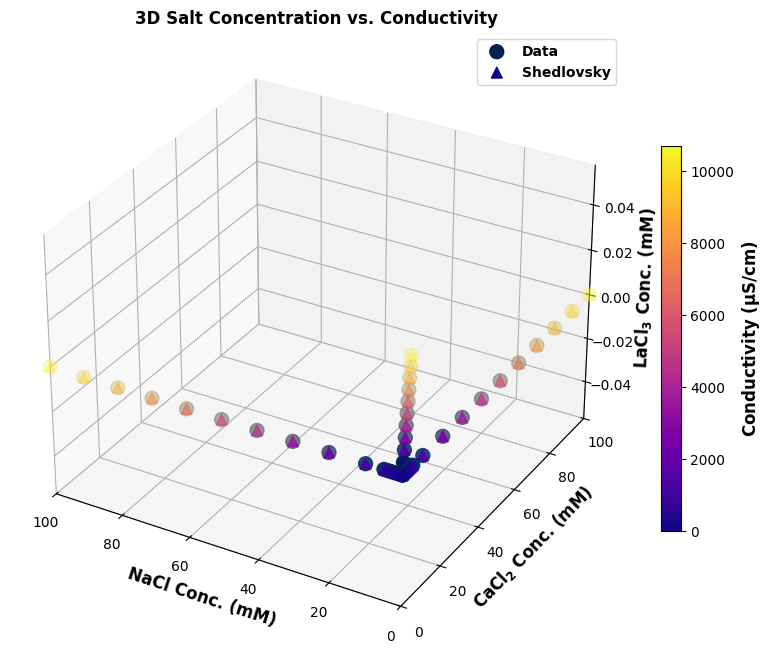

In [52]:
# bulk conductivity
specific_cond = [specific_cond_NaCl[i] + specific_cond_CaCl2[i] + specific_cond_LaCl3[i] for i in range(ndata)]
specific_cond2 = [specific_cond_NaCl_2[i] + specific_cond_CaCl2_2[i] + specific_cond_LaCl3_2[i] for i in range(ndata2)]
specific_cond3 = [specific_cond_NaCl_3[i] + specific_cond_CaCl2_3[i] + specific_cond_LaCl3_3[i] for i in range(ndata3)]

# making plot comparison of calculated and experimental conductivity
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot measured conductivity
sc1 = ax.scatter(NaCl_conc, CaCl2_conc, LaCl3_conc, c=cond_exp, cmap='cividis', s=100, label='Data')
sc2 = ax.scatter(NaCl_conc2, CaCl2_conc2, LaCl3_conc2, c=cond_exp2, cmap='cividis', s=100)
sc3 = ax.scatter(NaCl_conc3, CaCl2_conc3, LaCl3_conc3, c=cond_exp3, cmap='cividis', s=100)

# Overlay predicted with a different marker
sc4 = ax.scatter(NaCl_conc, CaCl2_conc, LaCl3_conc, c=specific_cond, cmap='plasma', marker='^', s=60, label='Shedlovsky')
sc5 = ax.scatter(NaCl_conc2, CaCl2_conc2, LaCl3_conc2, c=specific_cond2, cmap='plasma', marker='^', s=60)
sc6 = ax.scatter(NaCl_conc3, CaCl2_conc3, LaCl3_conc3, c=specific_cond3, cmap='plasma', marker='^', s=60)

# Colorbars
cb2 = plt.colorbar(sc4, ax=ax, shrink=0.5, pad=0.05)
cb2.set_label('Conductivity ($\mathbf{\mu}$S/cm)', fontsize=12,fontweight='bold')

ax.set_xlim(100, 0)
ax.set_ylim(0, 100)

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)

ax.set_title('3D Salt Concentration vs. Conductivity', fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_zlabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig("shedlovsky_three_salts.png")
plt.show()

In [55]:
e = [specific_cond[i] - cond_exp[i] for i in range(ndata)]
e2 = [specific_cond2[i] - cond_exp2[i] for i in range(ndata2)]
e3 = [specific_cond3[i] - cond_exp3[i] for i in range(ndata3)]

# residuals fraction
residuals_percent = [100*e[i]/cond_exp[i] for i in range(ndata)]
residuals_percent2 = [100*e2[i]/cond_exp2[i] for i in range(ndata2)]
residuals_percent3 = [100*e3[i]/cond_exp3[i] for i in range(ndata3)]

residuals_percent2_2 = residuals_percent[1:]
residuals_percent22_2 = residuals_percent2[1:]
residuals_percent23_2 = residuals_percent3[1:]

# absolute value of relative error
residuals_percent2_2_abs = [np.abs(residuals_percent2_2[i]) for i in range(ndata-1)]
residuals_percent22_2_abs = [np.abs(residuals_percent22_2[i]) for i in range(ndata2-1)]
residuals_percent23_2_abs = [np.abs(residuals_percent23_2[i]) for i in range(ndata3-1)]

print(np.mean(residuals_percent2_2_abs))
print(np.mean(residuals_percent22_2_abs))
print(np.mean(residuals_percent23_2_abs))

0.9365513546256506
2.1116717975037465
1.015297163325273


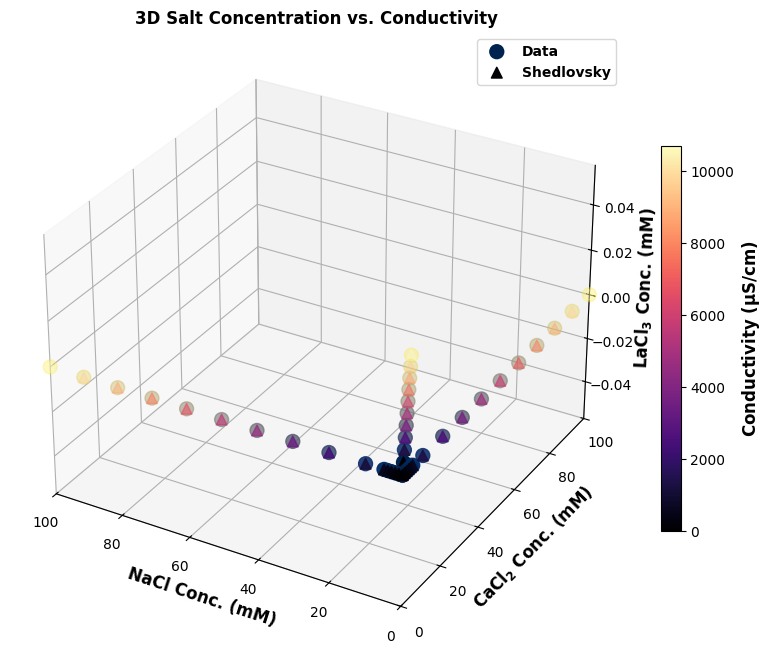

In [40]:
# bulk conductivity
specific_cond = [specific_cond_NaCl[i] + specific_cond_CaCl2[i] + specific_cond_LaCl3[i] for i in range(ndata)]
specific_cond2 = [specific_cond_NaCl_2[i] + specific_cond_CaCl2_2[i] + specific_cond_LaCl3_2[i] for i in range(ndata2)]
specific_cond3 = [specific_cond_NaCl_3[i] + specific_cond_CaCl2_3[i] + specific_cond_LaCl3_3[i] for i in range(ndata3)]

# making plot comparison of calculated and experimental conductivity
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot measured conductivity
sc1 = ax.scatter(NaCl_conc, CaCl2_conc, LaCl3_conc, c=cond_exp, cmap='cividis', s=100, label='Data')
sc2 = ax.scatter(NaCl_conc2, CaCl2_conc2, LaCl3_conc2, c=cond_exp2, cmap='cividis', s=100)
sc3 = ax.scatter(NaCl_conc3, CaCl2_conc3, LaCl3_conc3, c=cond_exp3, cmap='cividis', s=100)

# Overlay predicted with a different marker
sc4 = ax.scatter(NaCl_conc, CaCl2_conc, LaCl3_conc, c=specific_cond, cmap='magma', marker='^', s=60, label='Shedlovsky')
sc5 = ax.scatter(NaCl_conc2, CaCl2_conc2, LaCl3_conc2, c=specific_cond2, cmap='magma', marker='^', s=60)
sc6 = ax.scatter(NaCl_conc3, CaCl2_conc3, LaCl3_conc3, c=specific_cond3, cmap='magma', marker='^', s=60)

# Colorbars
cb2 = plt.colorbar(sc4, ax=ax, shrink=0.5, pad=0.05)
cb2.set_label('Conductivity ($\mathbf{\mu}$S/cm)', fontsize=12,fontweight='bold')

ax.set_xlim(100, 0)
ax.set_ylim(0, 100)

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)

ax.set_title('3D Salt Concentration vs. Conductivity', fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_ylabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.set_zlabel("LaC$\mathbf{l_3}$ Conc. (mM)", fontsize=12,fontweight='bold')
ax.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig("shedlovsky_three_salts.png")
plt.show()

## Data 2